In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('GDSC_dataset.csv')
df2 = pd.read_csv('model_list_latest.csv')
gf = pd.read_csv('genomic_features.csv', low_memory=False)

In [3]:
df.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


# Column Breakdown

COSMIC_ID: Unique identifier for the cancer cell line in the COSMIC database.

CELL_LINE_NAME: Name of the cancer cell line used in the drug screening experiment.

TCGA_DESC: Cancer type label based on The Cancer Genome Atlas abbreviation system.

DRUG_ID: Unique identifier assigned to each screened drug.

DRUG_NAME: Name of the drug tested on the cell line.

LN_IC50: Natural log of the half-maximal inhibitory concentration (IC50), used as the main drug-response target.

AUC: Area under the dose-response curve, summarizing the overall drug response across tested concentrations.

Z_SCORE: Standardized drug-response score used for relative comparison across observations.

GDSC Tissue descriptor 1: Broad tissue or organ-system category for the cell line.

GDSC Tissue descriptor 2: More specific tissue or disease subtype within the broader tissue category.

Cancer Type (matching TCGA label): Cancer-type label aligned to TCGA naming, likely intended to match or support TCGA_DESC.

Microsatellite instability Status (MSI): Indicates whether the cell line shows microsatellite instability status, such as MSI or stable forms. The source paper explicitly includes MSI as one of the genomic factors analyzed in relation to drug response.

Screen Medium: The culture medium used during the drug screening assay. The paper notes that cell lines were grown in different media during screening, which supports this column as assay-condition metadata.

Growth Properties: Describes how the cell line grows in culture, such as adherent or suspension.

CNA: Indicates whether copy number alteration data is available for that cell line. The paper describes copy number analysis as one of the genomic characterizations used in the GDSC study.

Gene Expression: Indicates whether gene expression data is available for that cell line. The paper states that transcriptional profiling was included in the study.

Methylation: Indicates whether methylation data is available for that cell line.

TARGET: The main molecular target of the drug, such as a gene or protein the drug is intended to act on.

TARGET_PATHWAY: The biological pathway associated with the drug’s target or mechanism of action.

# To confirm why we are using IC50 over the other 2

In [4]:
# to check the missing values of the 3 possible choices
df[['AUC', 'LN_IC50', 'Z_SCORE']].isna().sum()

AUC        0
LN_IC50    0
Z_SCORE    0
dtype: int64

- So no missing values

array([[<Axes: title={'center': 'AUC'}>,
        <Axes: title={'center': 'LN_IC50'}>],
       [<Axes: title={'center': 'Z_SCORE'}>, <Axes: >]], dtype=object)

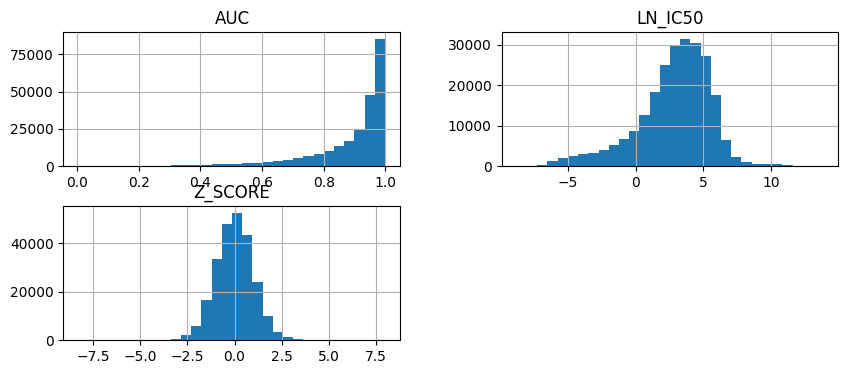

In [5]:
# to check the distribution
df[['AUC', 'LN_IC50', 'Z_SCORE']].hist(bins=30, figsize=(10,4))

AUC 
- It does not look spread out; it is compressed near a boundary. This can make regression harder to interpret, because many observations are crowded together. 
Ln-ic50
- It has a broad range (spread out) and a semi-perfect normal distribution curve. This helps with the regression approach as it usually benefits from a target with a reasonable spread. Also, it is easier to identify more sensitive or more resistant.
Z-score
- It looks the most symmetrical and centered, but z-scores are standardized. It is not absolute as ln-ic50 and also is not easily interpretable.

In [7]:
# to check for outlier
outlier_mask = (df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR))
outlier_mask.sum()

NameError: name 'cols' is not defined

AUC has a lot of outliers, which is clear from the distruibtuion. LN_IC50 also has some outliers but compared to AUC, it is much better. Although z-score has less outliers compared to the rest, making it more statistically better. It is still standardized and also it does not have an interpretable basis, like ic50.


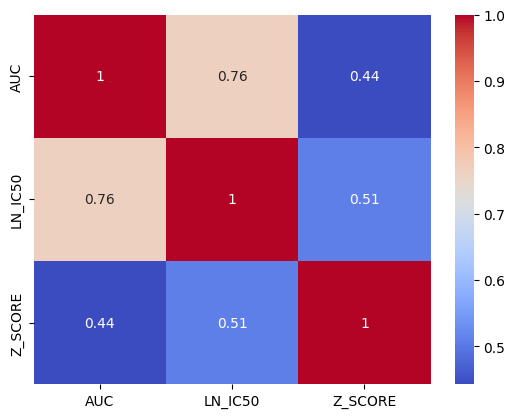

In [8]:
# correlation check through heatmap
sns.heatmap(df[['AUC', 'LN_IC50', 'Z_SCORE']].corr(), annot=True, cmap='coolwarm')
plt.show()


It shows that AUC and LN_IC50 are strongly related (r = 0.76), meaning they capture much of the same drug-response pattern, while Z_SCORE has only moderate relationships with LN_IC50 (r = 0.51) and AUC (r = 0.44). This suggests that LN_IC50 can represent the main response signal well, while Z_SCORE behaves more like a secondary standardized measure rather than the most direct biological target.

# Which of the potential feature columns are actually clean and usable as inputs?

C:\Users\shibu\AppData\Local\Temp\ipykernel_15452\1509366732.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


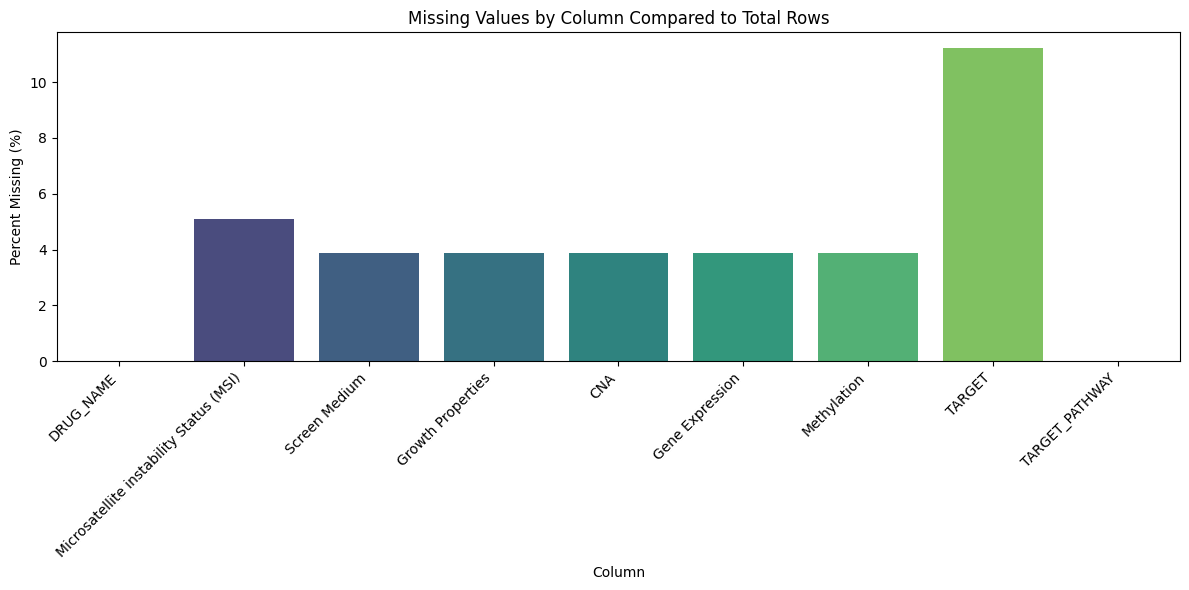

In [9]:
# Missing Values
cols_to_check = [
    "DRUG_NAME",
    "Microsatellite instability Status (MSI)",
    "Screen Medium",
    "Growth Properties",
    "CNA",
    "Gene Expression",
    "Methylation",
    "TARGET",
    "TARGET_PATHWAY"
]

# Calculate missing values
missing_counts = df[cols_to_check].isnull().sum()
total_rows = len(df)
missing_percent = (missing_counts / total_rows) * 100

# Create a dataframe for plotting
missing_df = pd.DataFrame({
    "Column": cols_to_check,
    "Missing Values": missing_counts,
    "Percent Missing": missing_percent
})

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=missing_df,
    x="Column",
    y="Percent Missing",
    palette="viridis"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percent Missing (%)")
plt.title("Missing Values by Column Compared to Total Rows")
plt.tight_layout()
plt.show()



In [13]:
# Number of unique categories

unique_counts = df[cols_to_check].nunique()

print("Number of unique categories per column:")
print(unique_counts)

Number of unique categories per column:
DRUG_NAME                                  286
Microsatellite instability Status (MSI)      2
Screen Medium                                2
Growth Properties                            3
CNA                                          2
Gene Expression                              2
Methylation                                  2
TARGET                                     185
TARGET_PATHWAY                              24
dtype: int64


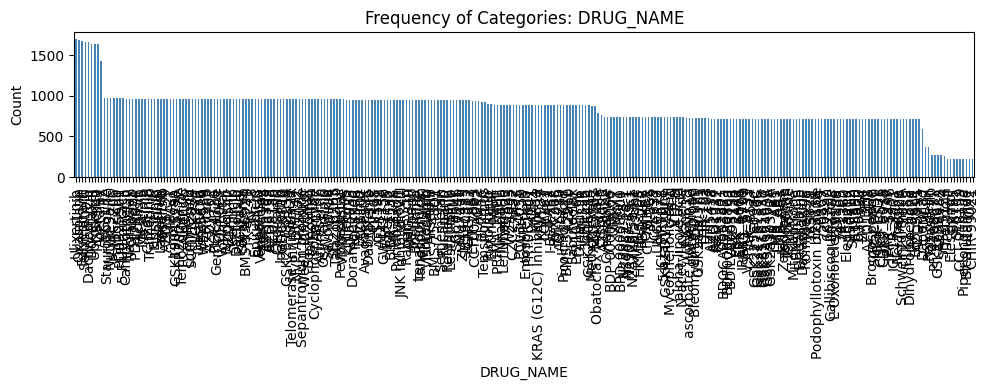

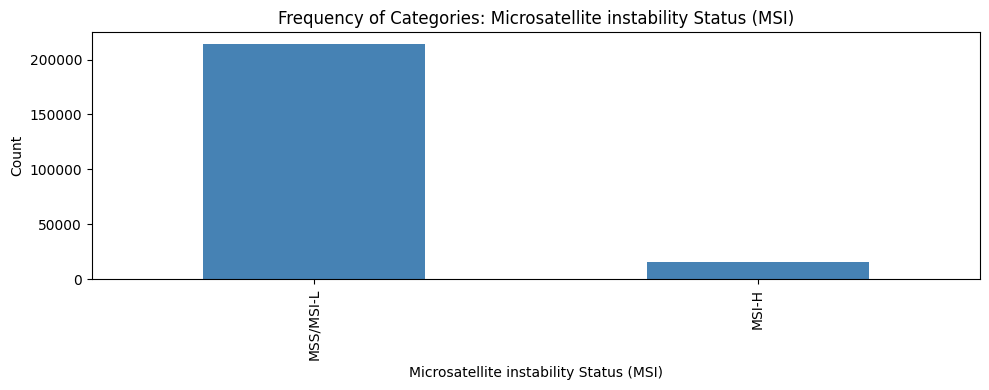

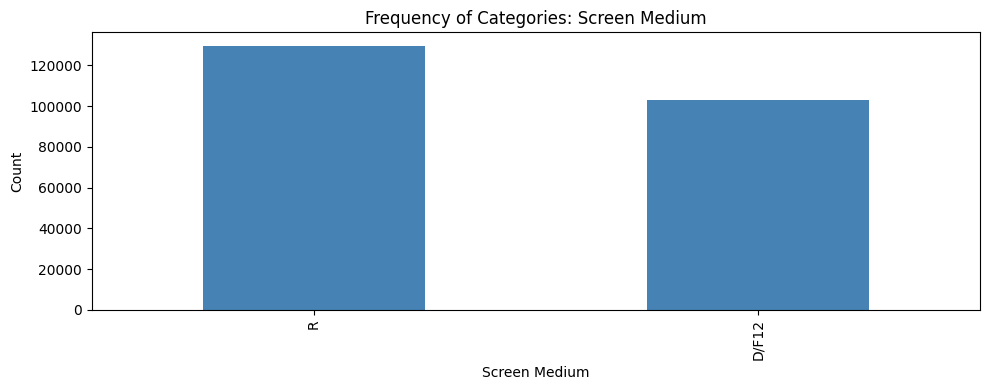

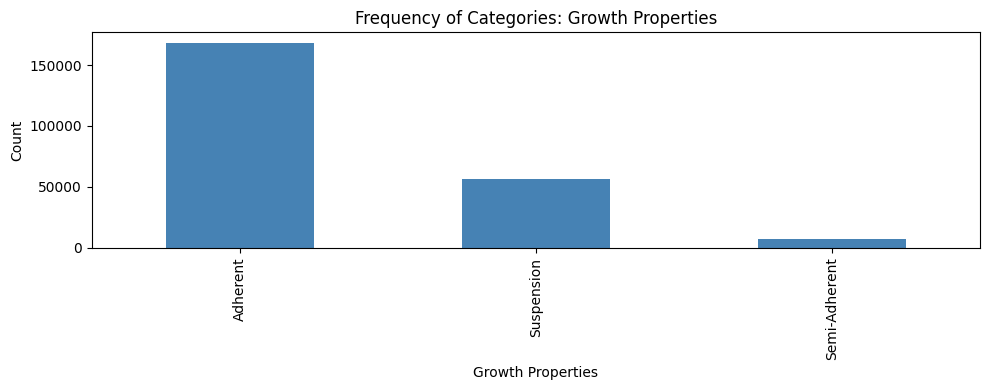

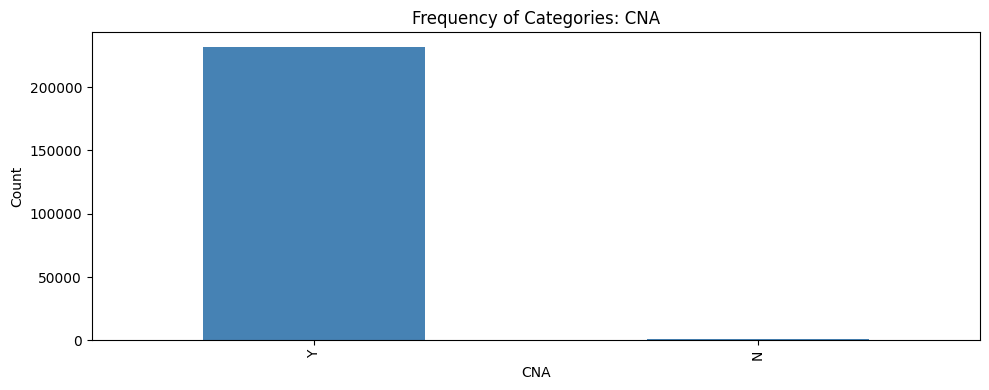

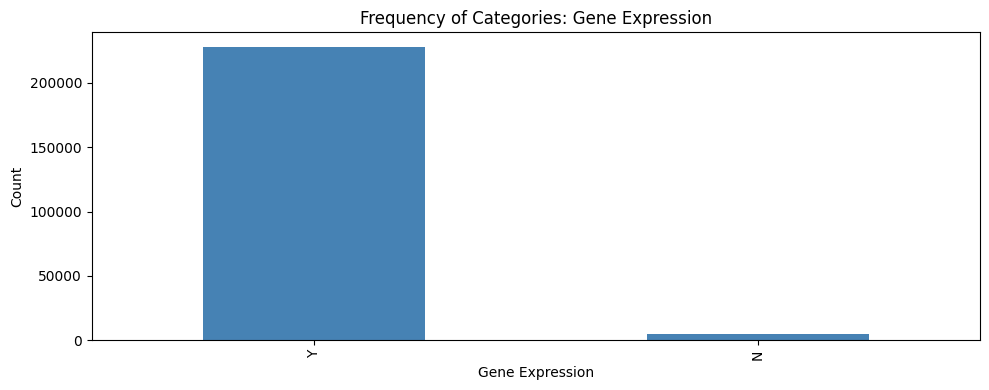

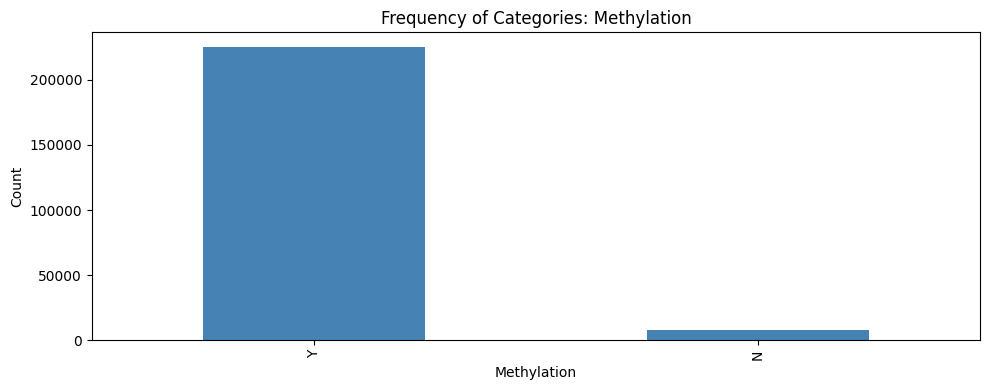

C:\Users\shibu\AppData\Local\Temp\ipykernel_15452\603488028.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


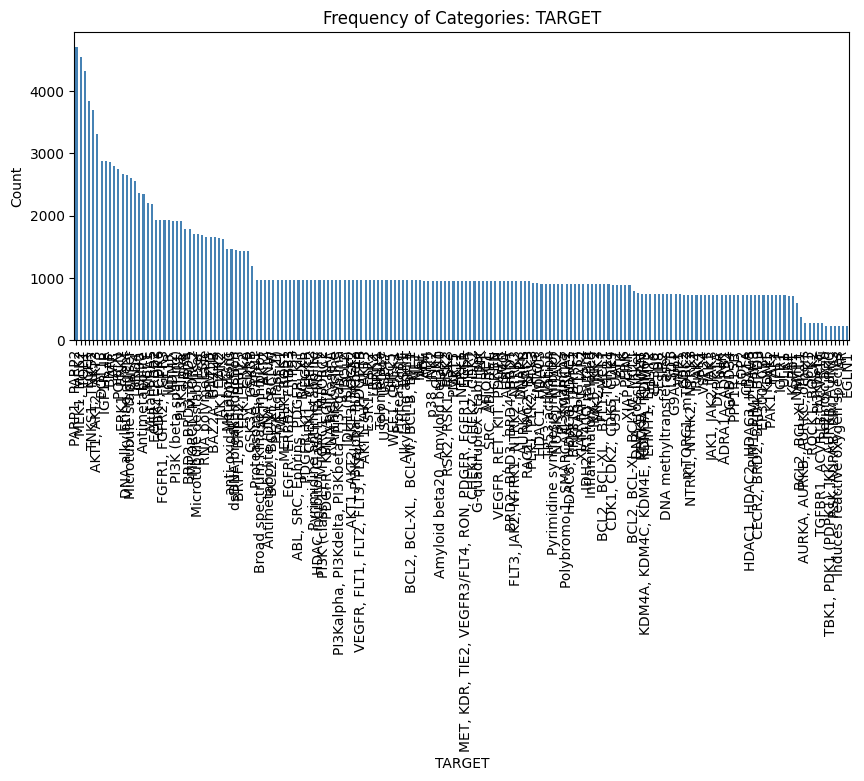

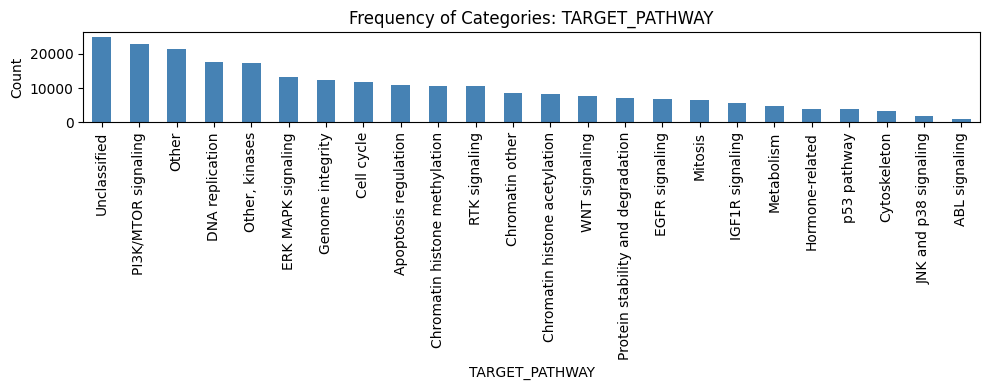

In [15]:
# Frequency of each category
for col in cols_to_check:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().plot(kind='bar', color='steelblue')
    plt.title(f"Frequency of Categories: {col}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



In [12]:
# messy/inconsistent labels
for col in cols_to_check:
    print(f"\n=== Potential messy labels in {col} ===")
    cleaned = df[col].astype(str).str.strip().str.lower()
    comparison = pd.DataFrame({
        "original": df[col],
        "cleaned": cleaned
    })
    mismatches = comparison[comparison["original"].str.lower() != comparison["cleaned"]]
    print(mismatches.head(10))


=== Potential messy labels in DRUG_NAME ===
              original        cleaned
227014  GSK-LSD1-2HCl   gsk-lsd1-2hcl
227015  GSK-LSD1-2HCl   gsk-lsd1-2hcl
227016  GSK-LSD1-2HCl   gsk-lsd1-2hcl
227017  GSK-LSD1-2HCl   gsk-lsd1-2hcl
227018  GSK-LSD1-2HCl   gsk-lsd1-2hcl
227019  GSK-LSD1-2HCl   gsk-lsd1-2hcl
227020  GSK-LSD1-2HCl   gsk-lsd1-2hcl
227021  GSK-LSD1-2HCl   gsk-lsd1-2hcl
227022  GSK-LSD1-2HCl   gsk-lsd1-2hcl
227023  GSK-LSD1-2HCl   gsk-lsd1-2hcl

=== Potential messy labels in Microsatellite instability Status (MSI) ===
    original cleaned
6        NaN     NaN
62       NaN     NaN
72       NaN     NaN
114      NaN     NaN
234      NaN     NaN
313      NaN     NaN
408      NaN     NaN
409      NaN     NaN
410      NaN     NaN
417      NaN     NaN

=== Potential messy labels in Screen Medium ===
    original cleaned
6        NaN     NaN
72       NaN     NaN
234      NaN     NaN
313      NaN     NaN
408      NaN     NaN
409      NaN     NaN
410      NaN     NaN
417      NaN  